02_conductance_dynamics.ipynb
compares AMPA conductance buildup in non-overlap vs overlap burst cases.

Chunk #1: Setup and helper functions to extract AMPA conductance over time and summarize conductance dynamics. The summary gives the peak conductance, peak time, and total conductance area for each sequence segment

In [13]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import (
    make_sleep_like_sequence,
    make_burst_sequence,
    burst_overlap_duration,
    g_AMPA_vector,
    g_NMDA_vector,
)

from src.dendrite import (
    simulate_dendrite,
    plot_input_raster,
    plot_voltage_traces,
    plot_ampa_conductances,
    plot_nmda_conductances,
)

here are the two cases we want to compare:
1. Non-overlapping bursts (burst onset step = 3 ms)
2. Failure case (burst onset step = 3.5 ms)

In [14]:
# Build two cases:
# 1. non-overlap burst
# 2. failure case with 3.5 ms overlap

nonoverlap_step_ms = 8.0

target_overlap_ms = 3.5
burst_span_ms = (burst_len - 1) * isi_ms
failure_step_ms = burst_span_ms - target_overlap_ms

print("burst span:", burst_span_ms, "ms")
print("non-overlap onset step:", nonoverlap_step_ms, "ms")
print("failure target overlap:", target_overlap_ms, "ms")
print("failure onset step:", failure_step_ms, "ms")


nonoverlap_events, nonoverlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=nonoverlap_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

failure_events, failure_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=failure_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)


times_non, V_non = simulate_dendrite(
    n_segments=n_segments,
    T=T,
    dt=dt,
    G_NMDA=G_NMDA,
    G_KIR=G_KIR,
    G_ax=G_ax,
    ampa_events=nonoverlap_events,
)

times_fail, V_fail = simulate_dendrite(
    n_segments=n_segments,
    T=T,
    dt=dt,
    G_NMDA=G_NMDA,
    G_KIR=G_KIR,
    G_ax=G_ax,
    ampa_events=failure_events,
)


G_ampa_non = get_ampa_matrix(
    times_non,
    n_segments=n_segments,
    events=nonoverlap_events,
)

G_ampa_fail = get_ampa_matrix(
    times_fail,
    n_segments=n_segments,
    events=failure_events,
)

burst span: 4.0 ms
non-overlap onset step: 8.0 ms
failure target overlap: 3.5 ms
failure onset step: 0.5 ms


In [15]:
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 120.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0
G_AMPA = 1.0
G_NMDA_syn = 1.0

start_time = 10.0
weight = 1.0

burst_len = 3
isi_ms = 2.0

In [16]:
def compute_conductance_history(times, n_segments, events, conductance_fn):
    """Compute AMPA or NMDA conductance history."""
    G = np.zeros((len(times), n_segments))

    for i, t in enumerate(times):
        G[i, :] = conductance_fn(float(t), n_segments, events)

    return G


def plot_conductance_history(times, G_hist, segments, title, ylabel, xlim=None):
    """Plot selected conductance traces."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, G_hist[:, int(seg)], label=f"segment {seg}")

    if xlim is not None:
        plt.xlim(*xlim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def summarize_conductance(times, G_hist, segments, title, t_start=0, t_end=None):
    """Print peak and area under conductance traces."""
    if t_end is None:
        t_end = times[-1]

    mask = (times >= t_start) & (times <= t_end)

    print(title)
    print("-" * len(title))

    for seg in segments:
        trace = G_hist[mask, int(seg)]
        area = np.trapz(trace, times[mask])
        peak = np.max(trace)

        print(f"seg {seg}: peak={peak:.3f}, area={area:.3f}")

In [17]:
# 1. Single-spike / sleep-like sequence
single_events, single_raster = make_sleep_like_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    step_ms=5.0,
    weight=weight,
)

# 2. Non-overlapping bursts
nonoverlap_onset_step_ms = 8.0

nonoverlap_events, nonoverlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=nonoverlap_onset_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

# 3. Strongly overlapping bursts
overlap_onset_step_ms = 0.5

overlap_events, overlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=overlap_onset_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

print("Non-overlap overlap duration:",
      burst_overlap_duration(nonoverlap_onset_step_ms, burst_len, isi_ms), "ms")

print("Overlap-case overlap duration:",
      burst_overlap_duration(overlap_onset_step_ms, burst_len, isi_ms), "ms")

Non-overlap overlap duration: 0.0 ms
Overlap-case overlap duration: 3.5 ms


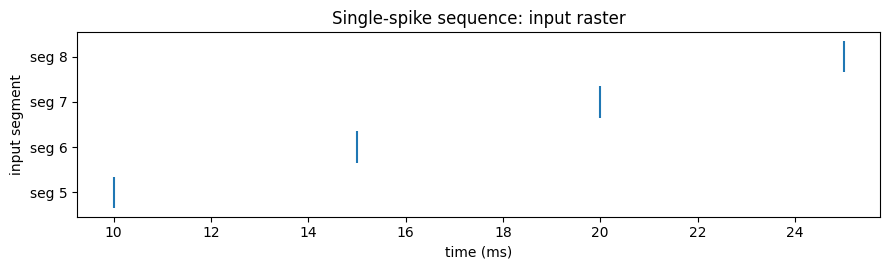

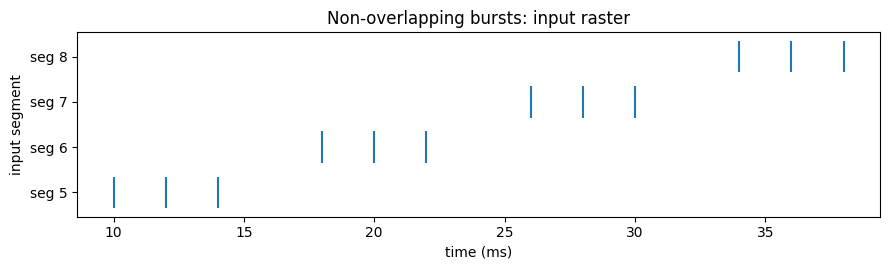

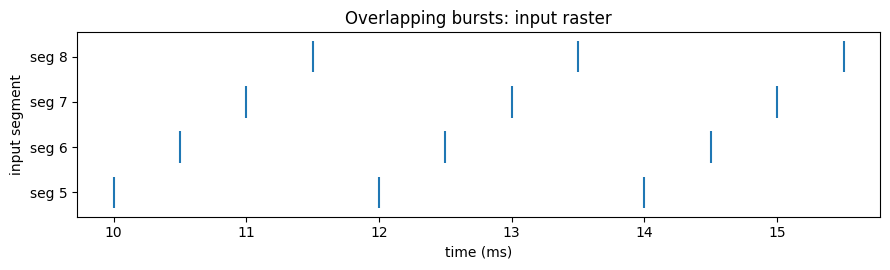

In [20]:
plot_input_raster(single_raster, "Single-spike sequence: input raster")
plot_input_raster(nonoverlap_raster, "Non-overlapping bursts: input raster")
plot_input_raster(overlap_raster, "Overlapping bursts: input raster")

In [21]:
times = np.arange(0, T + dt, dt)

G_ampa_single = compute_conductance_history(
    times, n_segments, single_events, g_AMPA_vector
)
G_nmda_single = compute_conductance_history(
    times, n_segments, single_events, g_NMDA_vector
)

G_ampa_non = compute_conductance_history(
    times, n_segments, nonoverlap_events, g_AMPA_vector
)
G_nmda_non = compute_conductance_history(
    times, n_segments, nonoverlap_events, g_NMDA_vector
)

G_ampa_overlap = compute_conductance_history(
    times, n_segments, overlap_events, g_AMPA_vector
)
G_nmda_overlap = compute_conductance_history(
    times, n_segments, overlap_events, g_NMDA_vector
)

In [22]:
times = np.arange(0, T + dt, dt)

G_ampa_single = compute_conductance_history(
    times, n_segments, single_events, g_AMPA_vector
)
G_nmda_single = compute_conductance_history(
    times, n_segments, single_events, g_NMDA_vector
)

G_ampa_non = compute_conductance_history(
    times, n_segments, nonoverlap_events, g_AMPA_vector
)
G_nmda_non = compute_conductance_history(
    times, n_segments, nonoverlap_events, g_NMDA_vector
)

G_ampa_overlap = compute_conductance_history(
    times, n_segments, overlap_events, g_AMPA_vector
)
G_nmda_overlap = compute_conductance_history(
    times, n_segments, overlap_events, g_NMDA_vector
)

In [28]:
def plot_conductance_history(
    times,
    G_hist,
    segments,
    title,
    ylabel,
    xlim=None,
    ylim=None,
):
    """Plot selected conductance traces with optional shared axes."""
    plt.figure(figsize=(9, 4))

    for seg in segments:
        plt.plot(times, G_hist[:, int(seg)], label=f"segment {seg}")

    if xlim is not None:
        plt.xlim(*xlim)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("time (ms)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [38]:
# Shared axis ranges for fair comparisons
xlim_ampa = (5, 45)
xlim_nmda = (5, 120)

# If AMPA is scaled to peak 0.25 and bursts have 3 spikes,
# this gives enough room for accumulation.
ylim_ampa = (0, 3)

# If NMDA is scaled to peak 0.60 and bursts have 3 spikes,
# accumulation can exceed 0.60.
ylim_nmda = (0, 2.0)

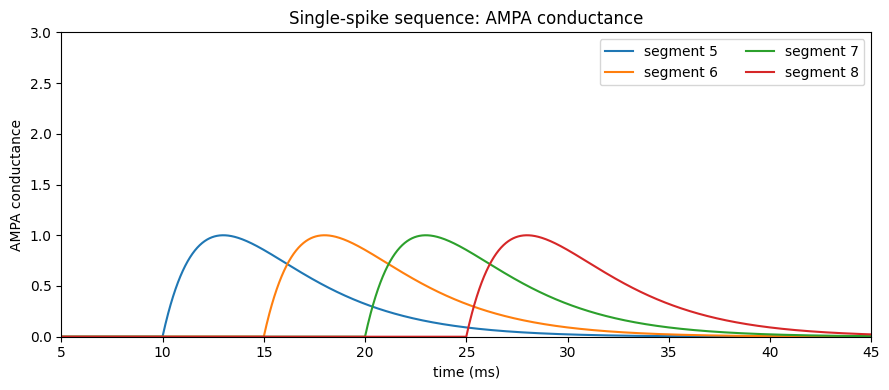

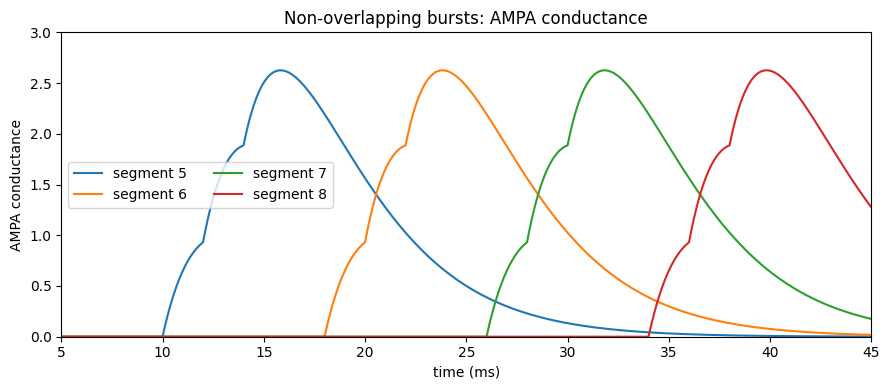

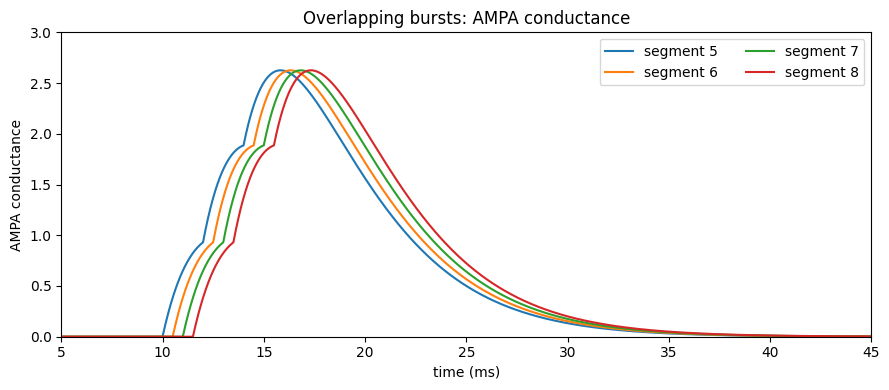

In [39]:
plot_conductance_history(
    times,
    G_ampa_single,
    sequence_segments,
    title="Single-spike sequence: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

plot_conductance_history(
    times,
    G_ampa_non,
    sequence_segments,
    title="Non-overlapping bursts: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)

plot_conductance_history(
    times,
    G_ampa_overlap,
    sequence_segments,
    title="Overlapping bursts: AMPA conductance",
    ylabel="AMPA conductance",
    xlim=xlim_ampa,
    ylim=ylim_ampa,
)